In [37]:
# important Libraries
import pandas as pd # Preprocessing, I/O, Cleaning
import numpy as np # Linear Algebra (Matrices Manipulation)
import matplotlib.pyplot as plt # Visualization
import seaborn as sns


In [3]:
Emp = pd.read_csv('Employee.csv')
Edu = pd.read_csv('EducationLevel.csv')
Per = pd.read_csv('PerformanceRating.csv')
Rating = pd.read_csv('RatingLevel.csv')
Sat = pd.read_csv('SatisfiedLevel.csv')

## Steps : 
1. Preprocessing and cleaning the data.
2. Explore and visualize the data to gain insights.

In [7]:
print(" Employee's Shape : {0}\n Education's Shape : {1}\n Performance's Shape : {2}\n Rating's Shape {3}\n Satisfied's Shape {4}\n"
      .format(Emp.shape, Edu.shape, Per.shape, Rating.shape, Sat.shape))

 Employee's Shape : (1470, 23)
 Education's Shape : (5, 2)
 Performance's Shape : (6709, 11)
 Rating's Shape (5, 2)
 Satisfied's Shape (5, 2)



In [10]:
print("Head For Every Data")
print(" \nEmployee\n : {0}\n Education\n : {1}\n Performance\n : {2}\n Rating\n {3}\n Satisfied\n {4}\n"
      .format(Emp.head(), Edu.head(), Per.head(), Rating.head(), Sat.head()))

Head For Every Data
 
Employee
 :   EmployeeID   FirstName  ... YearsSinceLastPromotion YearsWithCurrManager
0  3012-1A41    Leonelle  ...                       9                    7
1  CBCB-9C9D     Leonerd  ...                      10                    0
2  95D7-1CE9       Ahmed  ...                      10                    8
3  47A0-559B  Ermentrude  ...                      10                    0
4  42CC-040A       Stace  ...                       1                    6

[5 rows x 23 columns]
 Education
 :    EducationLevelID            EducationLevel
0                 1  No Formal Qualifications
1                 2              High School 
2                 3                Bachelors 
3                 4                  Masters 
4                 5                 Doctorate
 Performance
 :   PerformanceID EmployeeID  ... SelfRating  ManagerRating
0          PR01  79F7-78EC  ...          4              4
1          PR02  B61E-0F26  ...          4              3
2          PR

In [11]:
print("Informations about Every Data")
print(" \nEmployee\n : {0}\n Education\n : {1}\n Performance\n : {2}\n Rating\n {3}\n Satisfied\n {4}\n"
      .format(Emp.info(), Edu.info(), Per.info(), Rating.info(), Sat.info()))

Informations about Every Data
<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 23 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   EmployeeID               1470 non-null   str  
 1   FirstName                1470 non-null   str  
 2   LastName                 1470 non-null   str  
 3   Gender                   1470 non-null   str  
 4   Age                      1470 non-null   int64
 5   BusinessTravel           1470 non-null   str  
 6   Department               1470 non-null   str  
 7   DistanceFromHome (KM)    1470 non-null   int64
 8   State                    1470 non-null   str  
 9   Ethnicity                1470 non-null   str  
 10  Education                1470 non-null   int64
 11  EducationField           1470 non-null   str  
 12  JobRole                  1470 non-null   str  
 13  MaritalStatus            1470 non-null   str  
 14  Salary                   1470 non-nul

In [13]:
print("Description for Every Data")
print(" \nEmployee\n : {0}\n Education\n : {1}\n Performance\n : {2}\n Rating\n {3}\n Satisfied\n {4}\n"
      .format(Emp.describe(), Edu.describe(), Per.describe(), Rating.describe(), Sat.describe()))

Description for Every Data
 
Employee
 :                Age  ...  YearsWithCurrManager
count  1470.000000  ...           1470.000000
mean     28.989796  ...              2.239456
std       7.993055  ...              2.505774
min      18.000000  ...              0.000000
25%      23.000000  ...              0.000000
50%      26.000000  ...              1.000000
75%      34.000000  ...              4.000000
max      51.000000  ...             10.000000

[8 rows x 9 columns]
 Education
 :        EducationLevelID
count          5.000000
mean           3.000000
std            1.581139
min            1.000000
25%            2.000000
50%            3.000000
75%            4.000000
max            5.000000
 Performance
 :        EnvironmentSatisfaction  JobSatisfaction  ...   SelfRating  ManagerRating
count              6709.000000      6709.000000  ...  6709.000000    6709.000000
mean                  3.872559         3.430616  ...     3.984051       3.473394
std                   0.940701    

In [25]:
print("Checking The Nulls for Every Data") 
print(" Employee : {0}\n Education : {1}\n Performance : {2}\n Rating {3}\n Satisfied {4}\n"
      .format(Emp.isnull().sum().sum(), Edu.isnull().sum().sum(), Per.isnull().sum().sum(), Rating.isnull().sum().sum(), Sat.isnull().sum().sum()))

Checking The Nulls for Every Data
 Employee : 0
 Education : 0
 Performance : 0
 Rating 0
 Satisfied 0



In [29]:
print("Checking The Duplications for Every Data") 
print(" Employee : {0}\n Education : {1}\n Performance : {2}\n Rating {3}\n Satisfied {4}\n"
      .format(Emp.duplicated().sum(), Edu.duplicated().sum(), Per.duplicated().sum(), Rating.duplicated().sum(), Sat.duplicated().sum()))

Checking The Duplications for Every Data
 Employee : 0
 Education : 0
 Performance : 0
 Rating 0
 Satisfied 0



In [31]:
def boxplot_drawer(column_Name, data) :
    sns.boxplot(y = column_Name, data = data)


Outliers for Employee Data



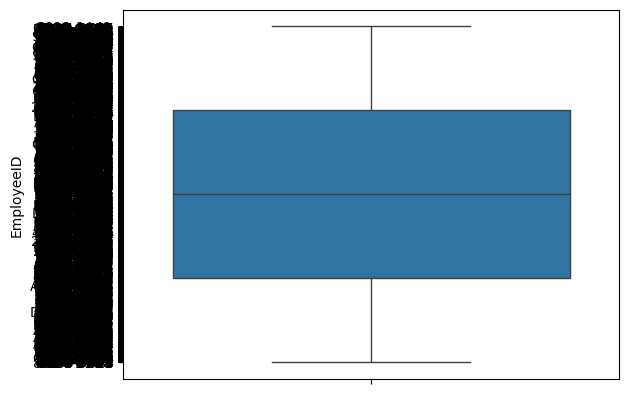

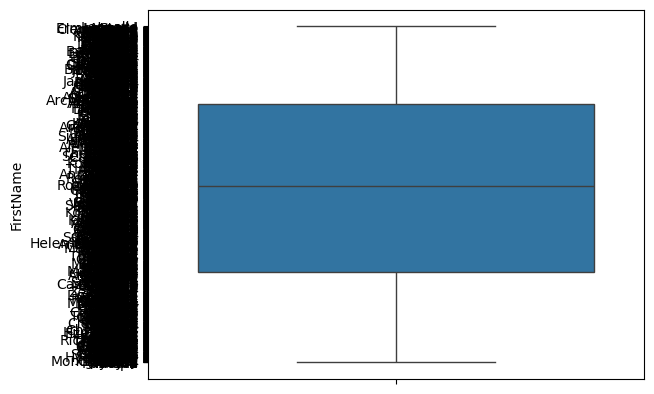

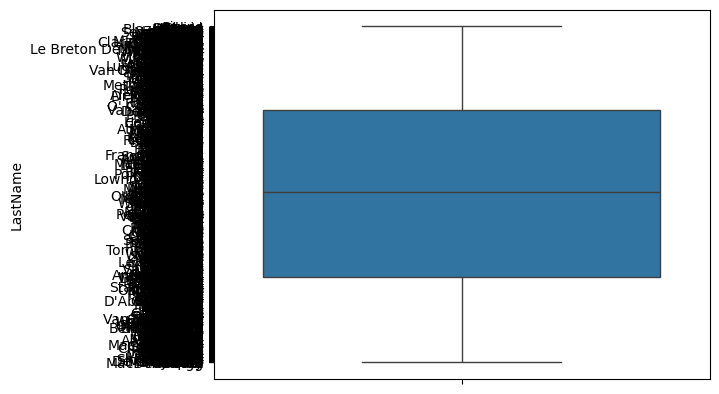

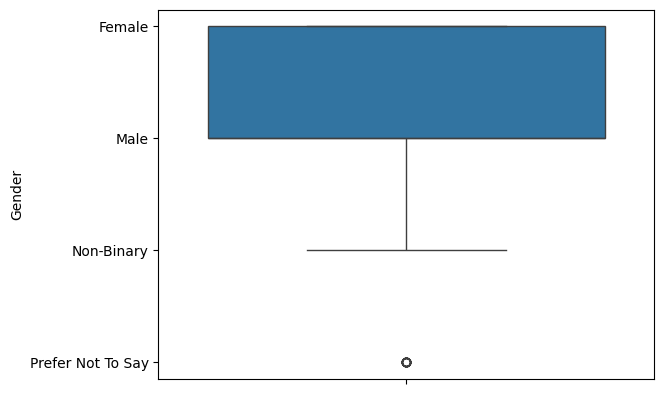

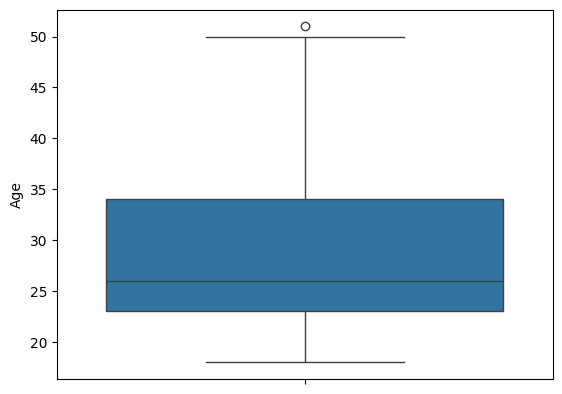

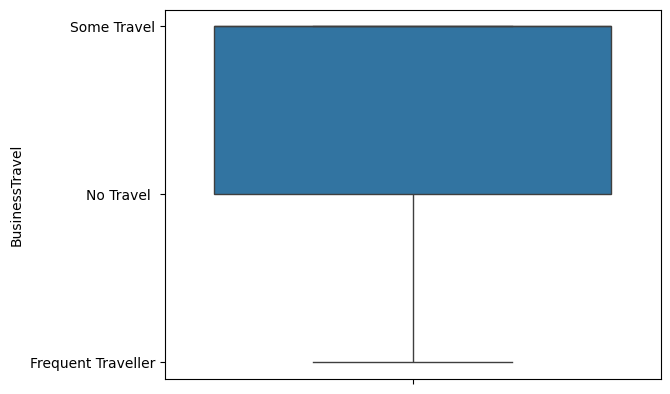

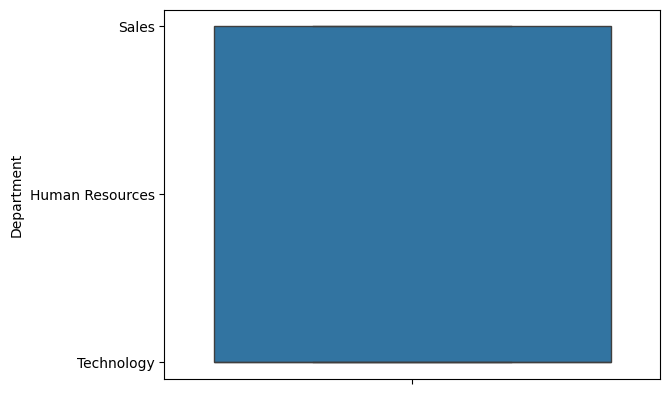

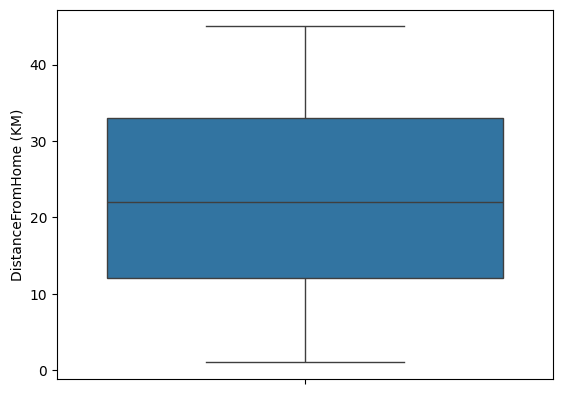

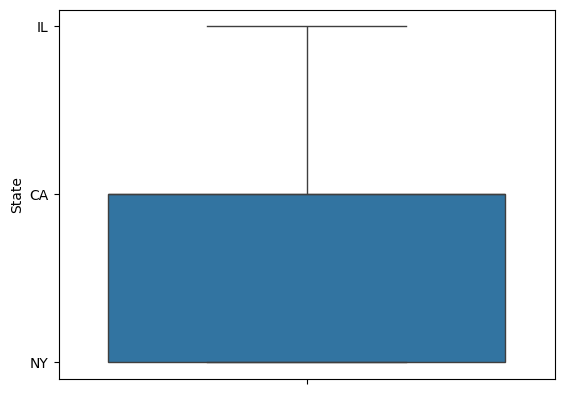

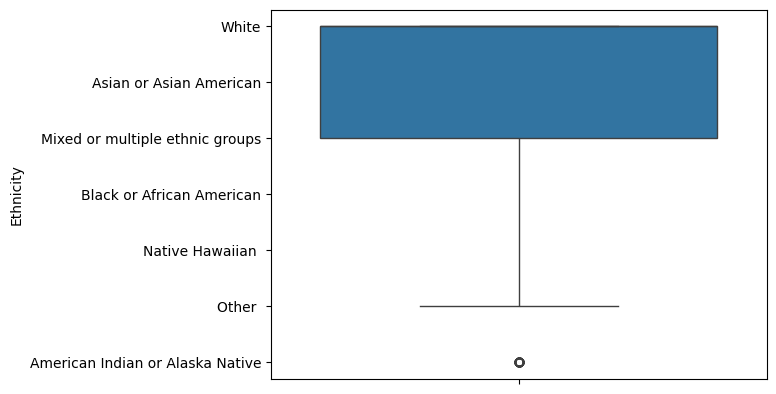

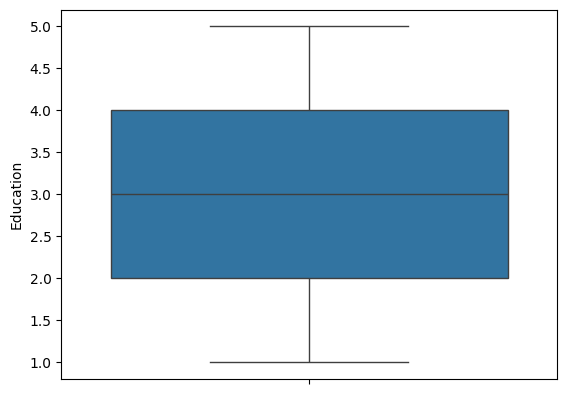

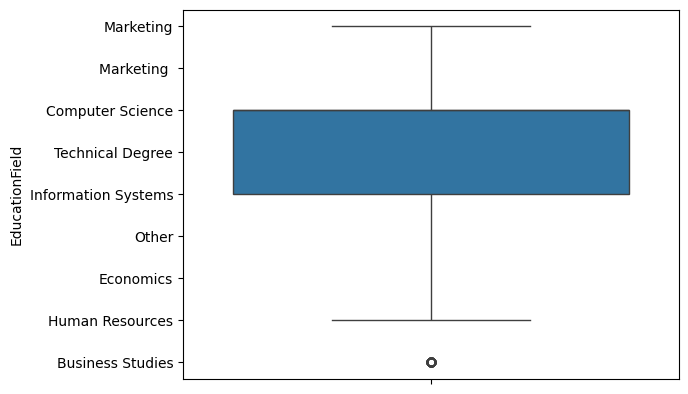

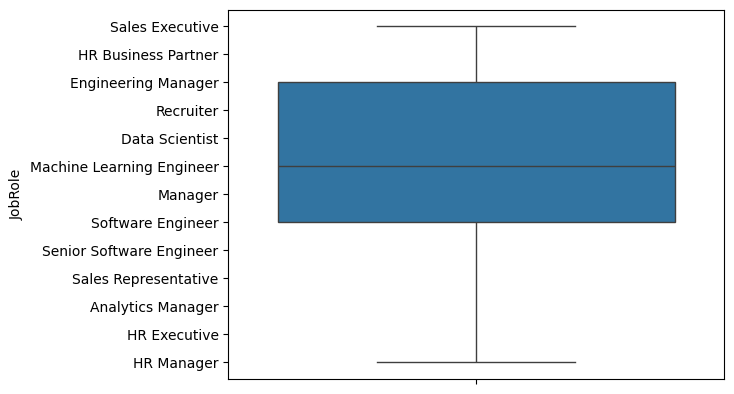

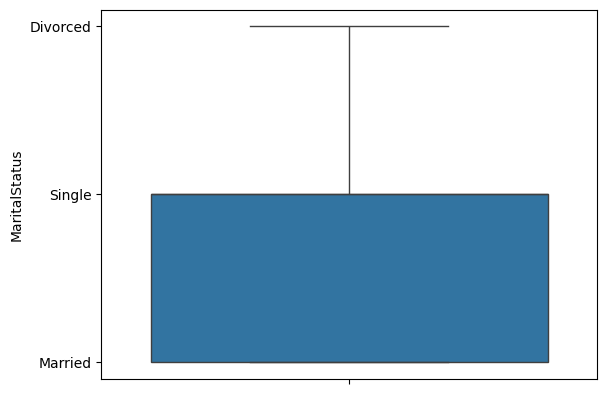

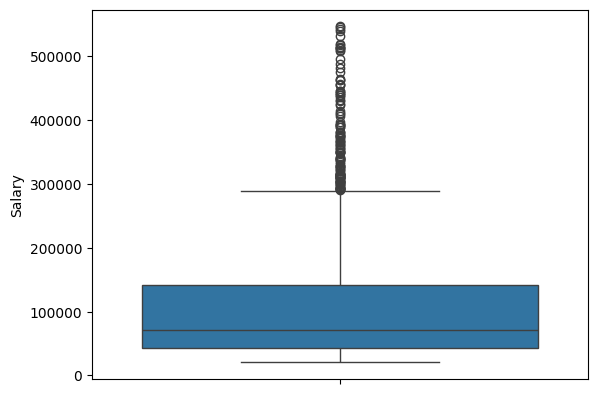

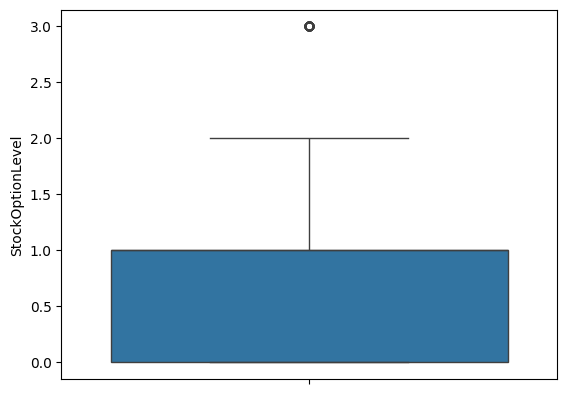

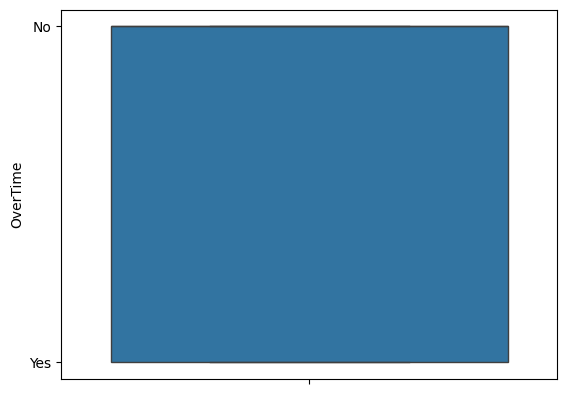

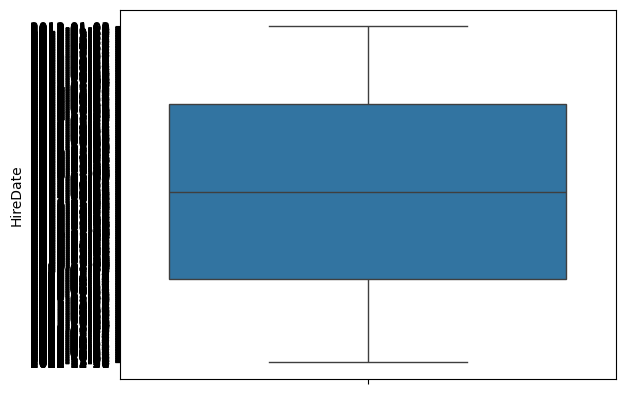

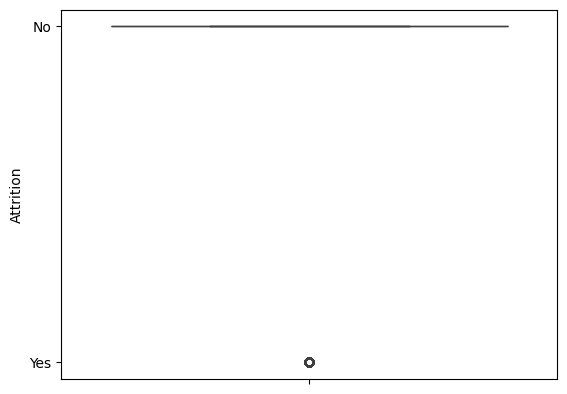

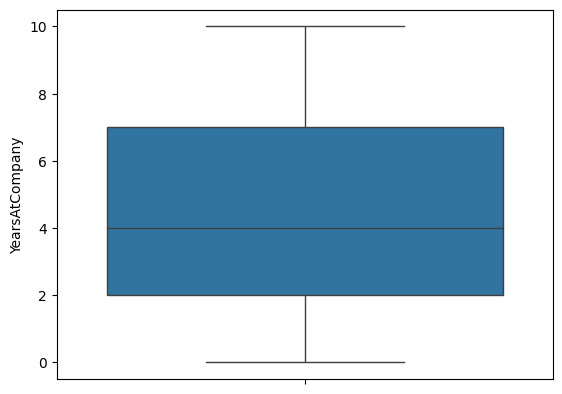

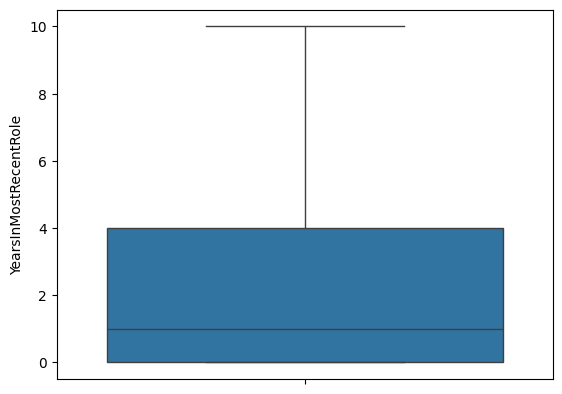

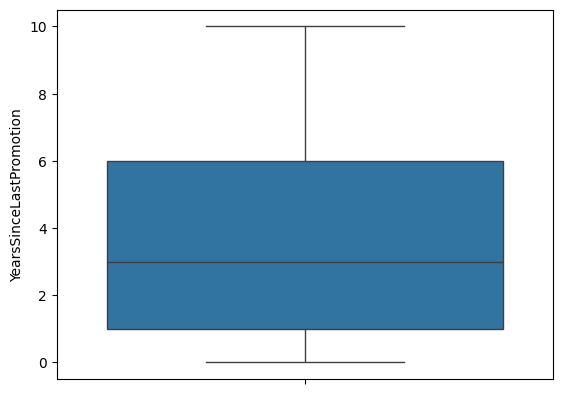

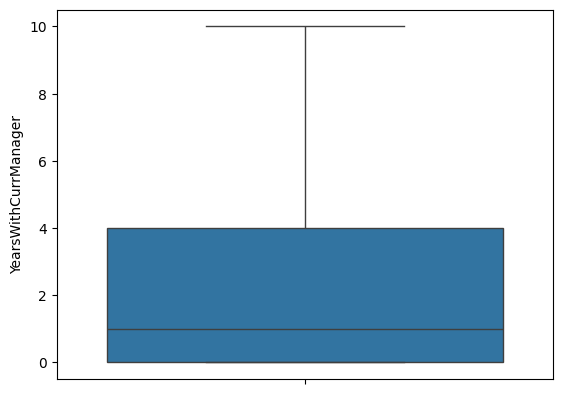

In [ ]:
print("Outliers for Employee Data\n")

for col in Emp :
    boxplot_drawer(col, Emp)
    plt.show()

In [52]:
def Remove_outliers(col, data) :
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    outlier_condition = (data[col] < q1-1.5*iqr) | (data[col] > q3+1.5*iqr)
    data.loc[outlier_condition] = np.nan
Remove_outliers('Salary', Emp)

In [53]:
Emp['Salary'].describe()

count      1152.000000
mean      66390.341146
std       34942.755581
min       20387.000000
25%       38333.000000
50%       57465.000000
75%       87791.250000
max      163950.000000
Name: Salary, dtype: float64

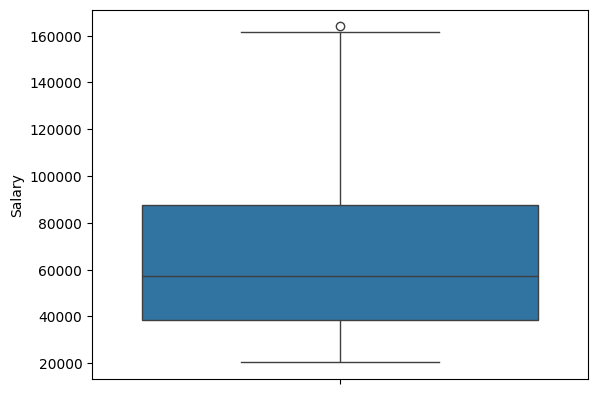

In [54]:
boxplot_drawer('Salary', Emp)

Outliers for Education Data



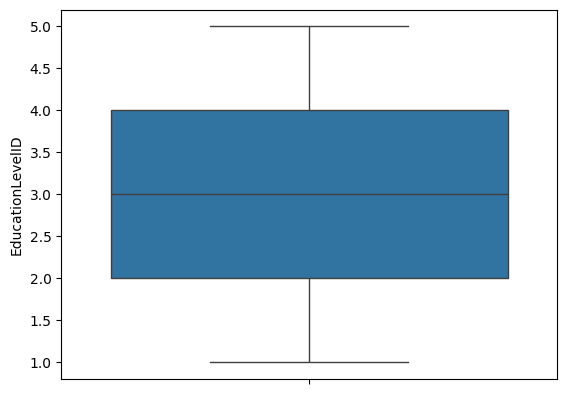

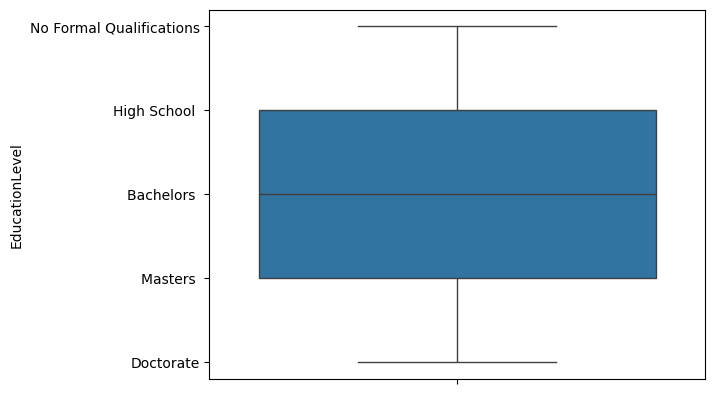

In [66]:
print("Outliers for Education Data\n")

for col in Edu :
    boxplot_drawer(col, Edu)
    plt.show()

Outliers for Performance Data



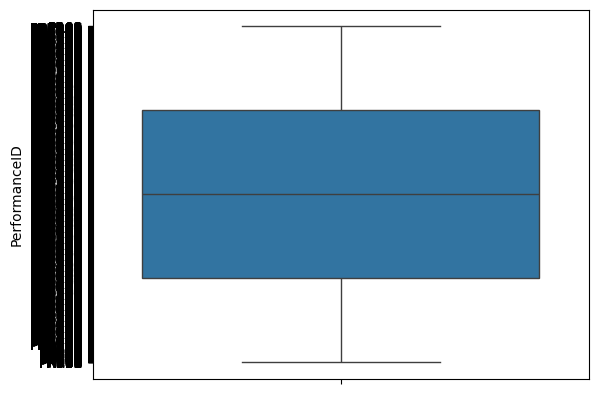

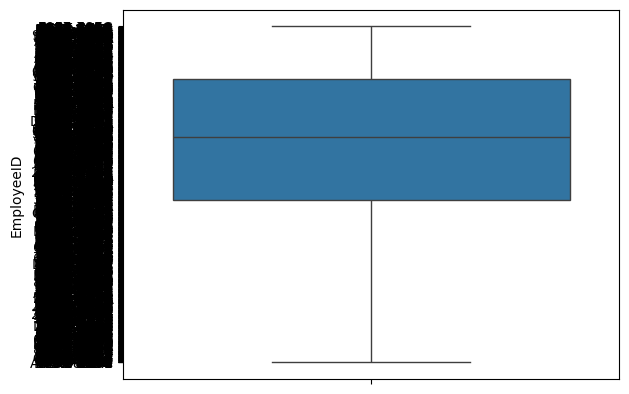

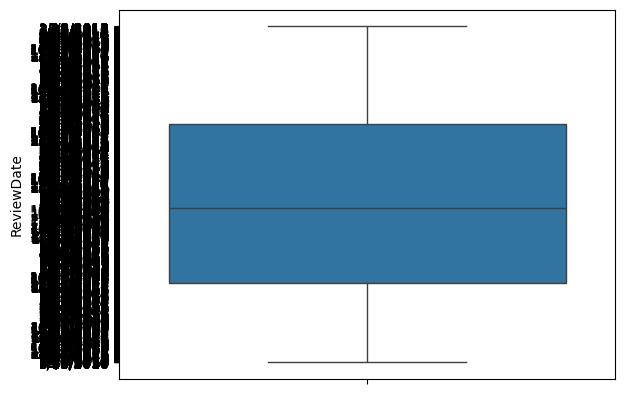

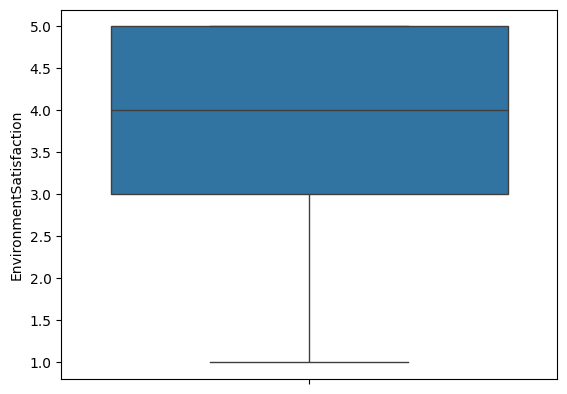

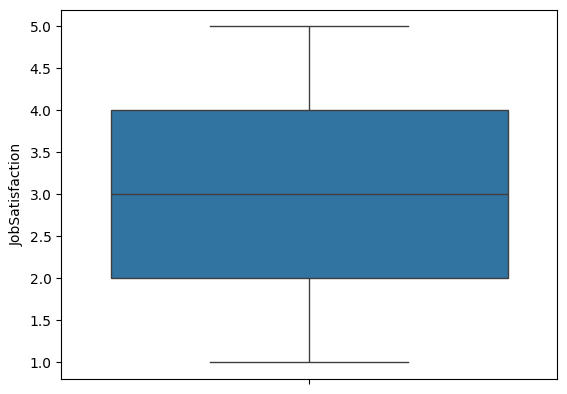

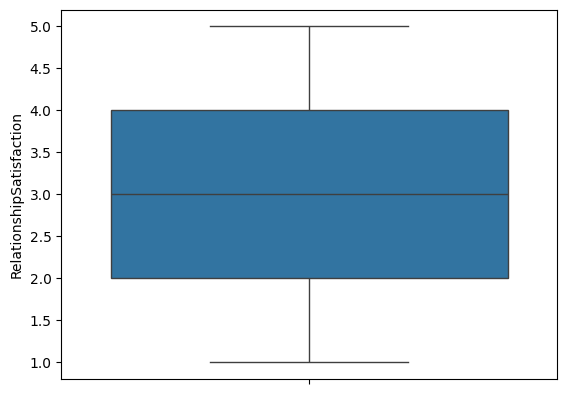

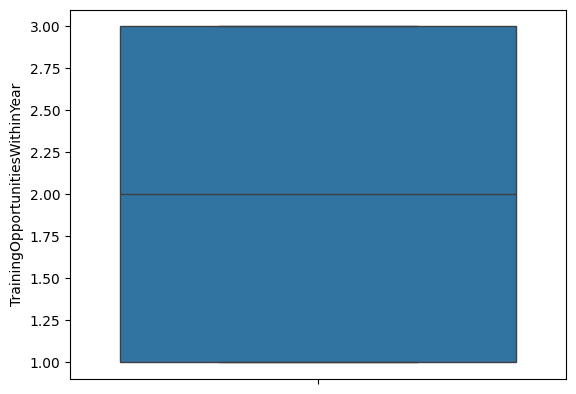

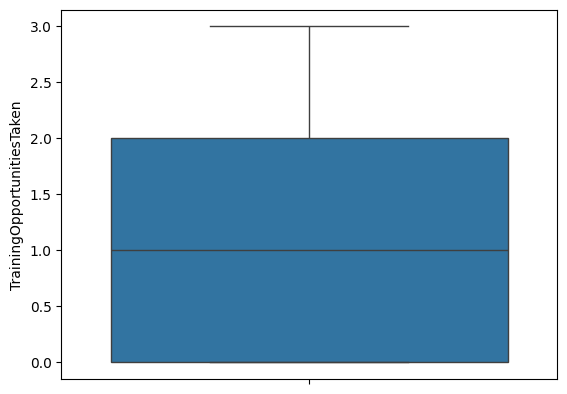

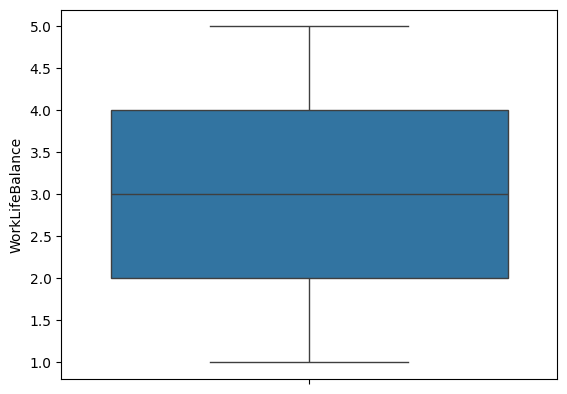

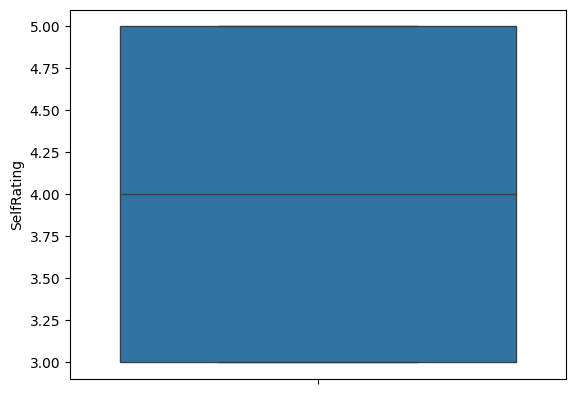

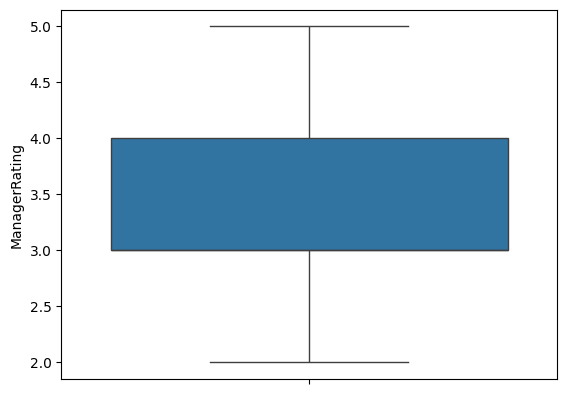

In [67]:
print("Outliers for Performance Data\n")

for col in Per :
    boxplot_drawer(col, Per)
    plt.show()

Outliers for Rating Data



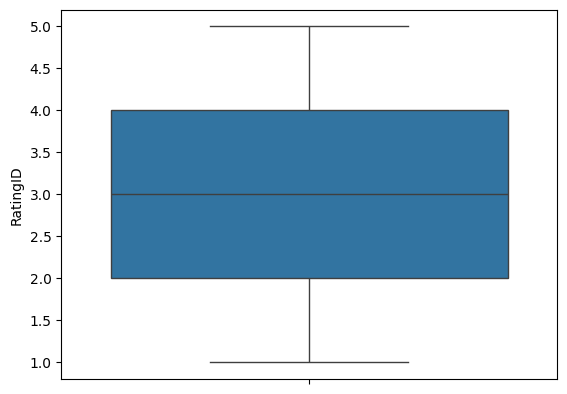

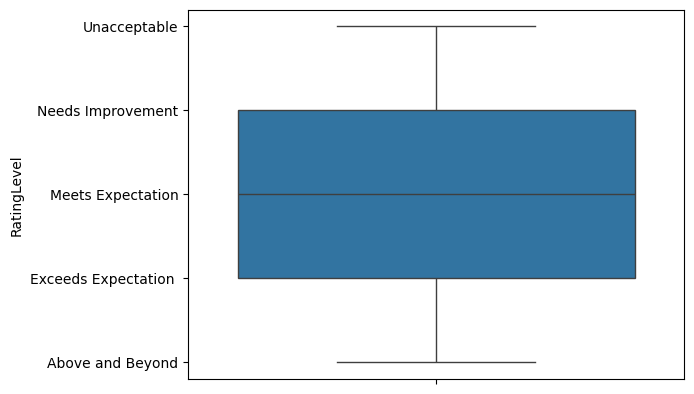

In [68]:
print("Outliers for Rating Data\n")

for col in Rating :
    boxplot_drawer(col, Rating)
    plt.show()

Outliers for Satisfied Data



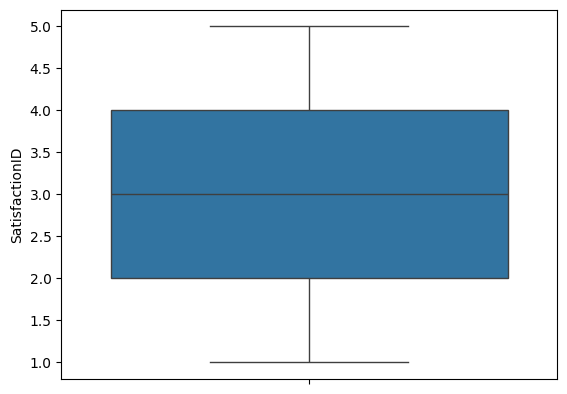

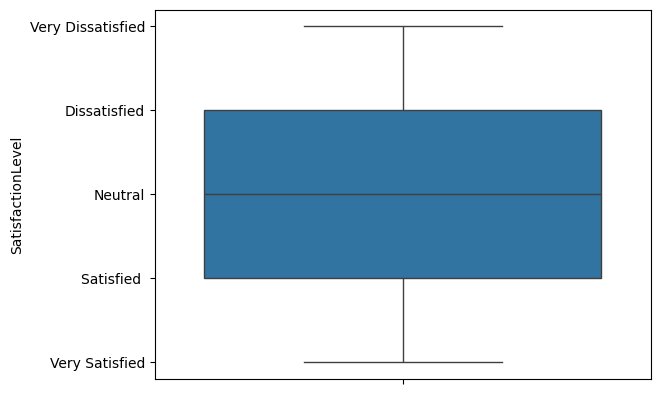

In [69]:
print("Outliers for Satisfied Data\n")

for col in Sat :
    boxplot_drawer(col, Sat)
    plt.show()

/tmp/ipykernel_46917/2060441384.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=Emp, x='Attrition', ax=axes[0, 0], palette='Set2')


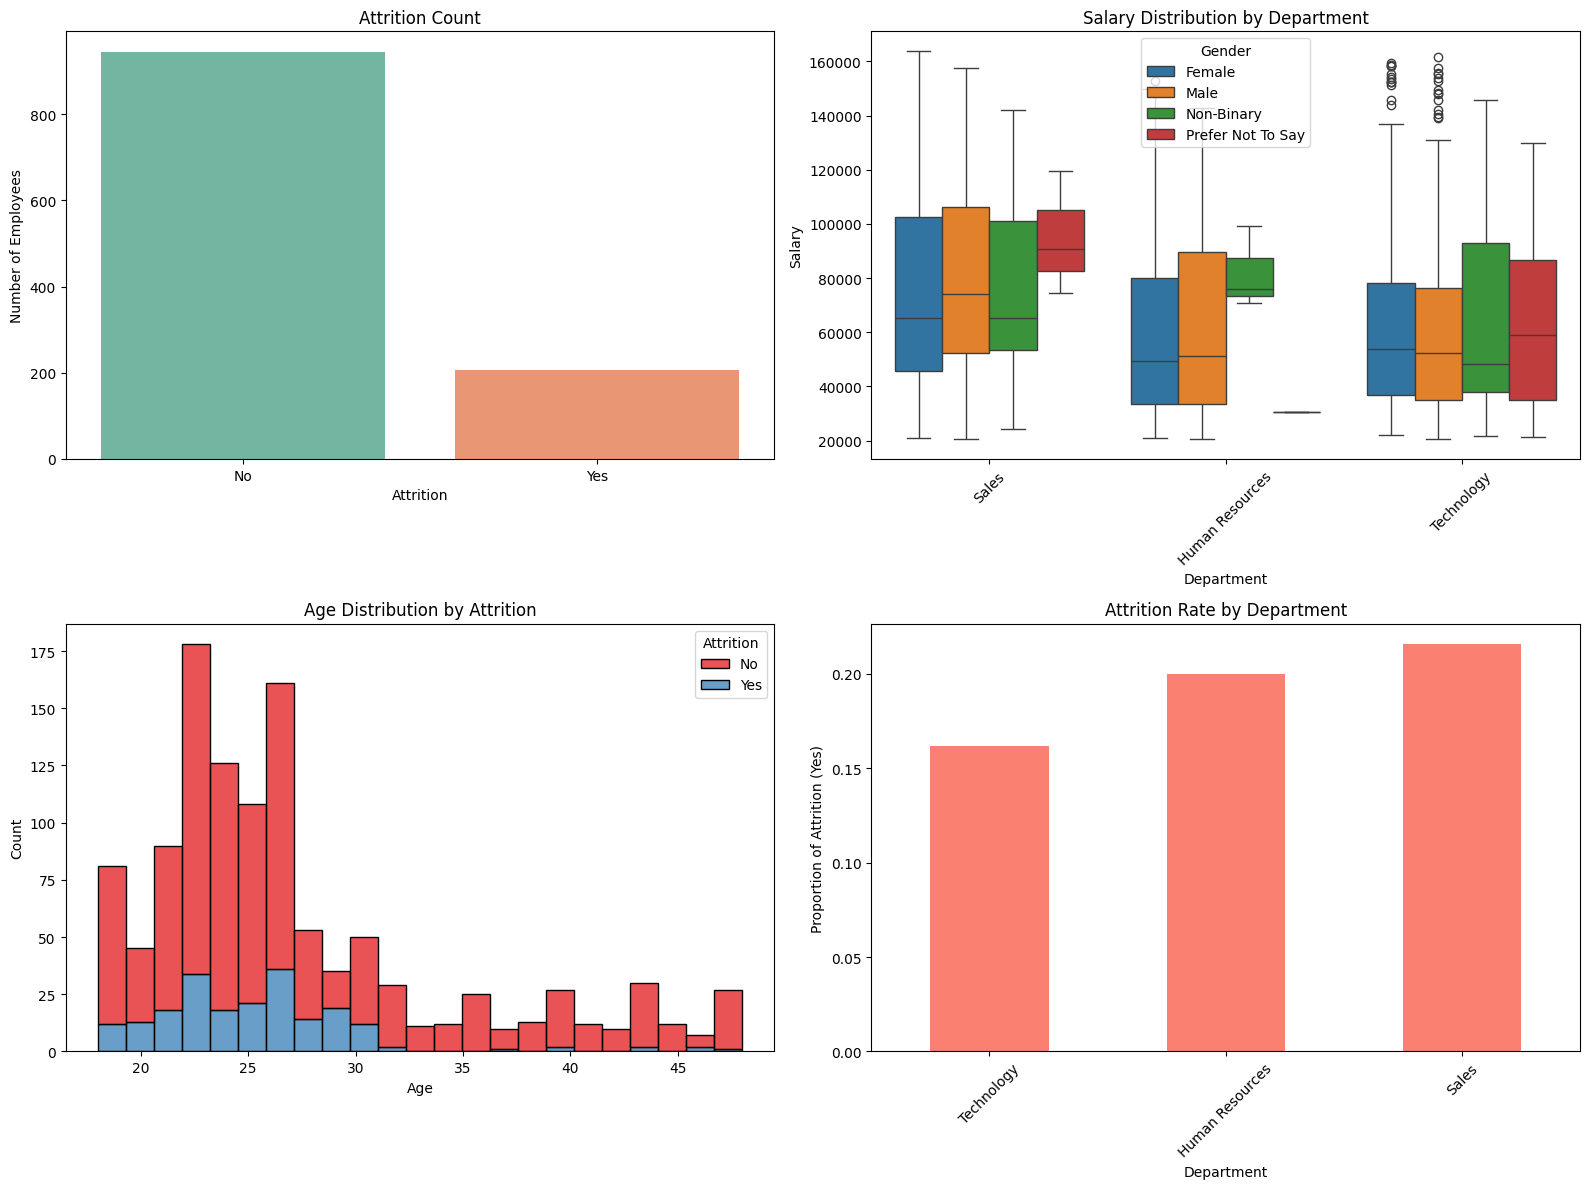

/tmp/ipykernel_46917/2060441384.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=Per, x='ManagerRating', y='SelfRating', ax=axes2[1], palette='Set3')


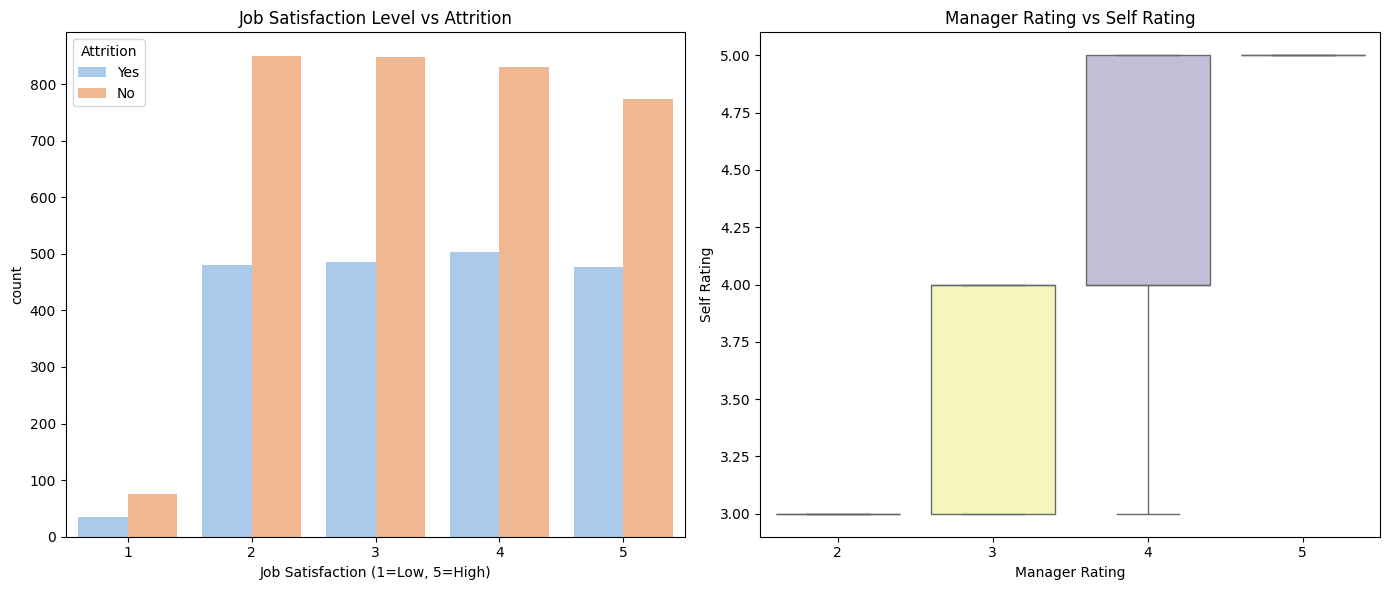

In [71]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Attrition count
sns.countplot(data=Emp, x='Attrition', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Attrition Count')
axes[0, 0].set_ylabel('Number of Employees')

# 2. Salary distribution by Department
sns.boxplot(data=Emp, x='Department', y='Salary', hue='Gender', ax=axes[0, 1])
axes[0, 1].set_title('Salary Distribution by Department')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Age Distribution by Attrition
sns.histplot(data=Emp, x='Age', hue='Attrition', multiple='stack', ax=axes[1, 0], palette='Set1')
axes[1, 0].set_title('Age Distribution by Attrition')

# 4. Department Attrition Proportion
# Calculate the percentage of 'Yes' and 'No' for Attrition per department
dept_attrition = Emp.groupby('Department')['Attrition'].value_counts(normalize=True).unstack()

if 'Yes' in dept_attrition.columns:
    # Plot only the 'Yes' proportion to see attrition rates
    dept_attrition['Yes'].sort_values().plot(kind='bar', color='salmon', ax=axes[1, 1])
    axes[1, 1].set_title('Attrition Rate by Department')
    axes[1, 1].set_ylabel('Proportion of Attrition (Yes)')
    axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Merge performance and employee data to connect ratings with attrition
df_perf_emp = pd.merge(
    Per, 
    Emp[['EmployeeID', 'Department', 'Attrition']], 
    on='EmployeeID', 
    how='inner'
)

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

# 1. Job Satisfaction vs Attrition
sns.countplot(data=df_perf_emp, x='JobSatisfaction', hue='Attrition', ax=axes2[0], palette='pastel')
axes2[0].set_title('Job Satisfaction Level vs Attrition')
axes2[0].set_xlabel('Job Satisfaction (1=Low, 5=High)')

# 2. Manager Rating vs Self Rating
sns.boxplot(data=Per, x='ManagerRating', y='SelfRating', ax=axes2[1], palette='Set3')
axes2[1].set_title('Manager Rating vs Self Rating')
axes2[1].set_xlabel('Manager Rating')
axes2[1].set_ylabel('Self Rating')

plt.tight_layout()
plt.show()